In [59]:
from src.analysis.hard_cases_analysis import analyse_hard_cases
from src.modeling import train_xgboost_model
from sklearn.metrics import mean_absolute_error
from src.core.config import MODEL_PATH,DATA_PROCESSED,RAW_DATA_PATH
import joblib
import pandas as pd
import numpy as np

In [60]:
model = joblib.load(MODEL_PATH)
x_test_path= DATA_PROCESSED/"X_test.joblib"
y_test_path= DATA_PROCESSED/"y_test.joblib"
x_train_path= DATA_PROCESSED/"X_train.joblib"
y_train_path= DATA_PROCESSED/"y_train.joblib"

X_test = joblib.load(x_test_path)
y_test = joblib.load(y_test_path)
X_train = joblib.load(x_train_path)
y_train = joblib.load(y_train_path)
pred=model.predict(X_test)

In [61]:
X_test['cyp2c9'].value_counts()

cyp2c9
2.0    821
1.5    140
1.0    126
0.5     15
0.0      4
Name: count, dtype: int64

In [62]:
X_test['vkorc1'].value_counts()

vkorc1
UNKNOWN    310
AA         294
AG         263
GG         239
Name: count, dtype: int64

In [67]:
len(X_test)

1106

In [64]:
y_pred_base = model.predict(X_test)
test_df = X_test.copy()
test_df['true_dose'] = y_test
test_df['pred_dose'] = y_pred_base
test_df['abs_error'] = np.abs(test_df['true_dose'] - test_df['pred_dose'])
test_df['within_20'] = (test_df['abs_error'] / test_df['true_dose']) <= 0.20

test_df['age_80_plus'] = test_df['age_decade'] >= 8 # 8 = "80-89" or "90+"

def subgroup_stats(df, mask, name):
    sub = df[mask]
    n = len(sub)
    if n == 0: return {'N': 0, 'MAE': np.nan, 'Within20%': np.nan}
    return {
        'N': n,
        'MAE': sub['abs_error'].mean().round(2),
        'Within20%': (sub['within_20'].mean() * 100).round(1)
    }

# Key subgroups clinicians care about
results = {}
results['Overall'] = subgroup_stats(test_df, np.ones(len(test_df), dtype=bool), 'Overall')
results['Age 80+'] = subgroup_stats(test_df, test_df['age_80_plus'], 'Age 80+')
results['CYP2C9 *3/*3'] = subgroup_stats(test_df, test_df['cyp2c9'] == 0.0, '*3/*3')
results['CYP2C9 *1/*1'] = subgroup_stats(test_df, test_df['cyp2c9'] == 2.0, '*1/*1')
results['BMI 30-40'] = subgroup_stats(test_df, (test_df['bmi'] >= 30) & (test_df['bmi'] < 40), 'BMI 30-40')
results['Amiodarone'] = subgroup_stats(test_df, test_df['amiodarone'] == 1, 'Amiodarone')
results['Vkorc1_AA'] = subgroup_stats(test_df, test_df['vkorc1'] == 'AA', 'Vkorc1_AA')
results['Vkorc1_UNKNOWN'] = subgroup_stats(test_df, test_df['vkorc1'] == 'UNKNOWN', 'Vkorc1_UNKNOWN')
results['Vkorc1_GG'] = subgroup_stats(test_df, test_df['vkorc1'] == 'GG', 'Vkorc1_GG')


pd.DataFrame(results).T


,N,MAE,Within20%
Overall,1106.0,9.45,42.9
Age 80+,133.0,6.71,48.1
CYP2C9 *3/*3,4.0,6.75,25.0
CYP2C9 *1/*1,821.0,9.84,43.6
BMI 30-40,186.0,11.25,47.8
Amiodarone,86.0,7.84,48.8
Vkorc1_AA,294.0,5.95,43.9
Vkorc1_UNKNOWN,310.0,11.12,35.8
Vkorc1_GG,239.0,12.33,46.0


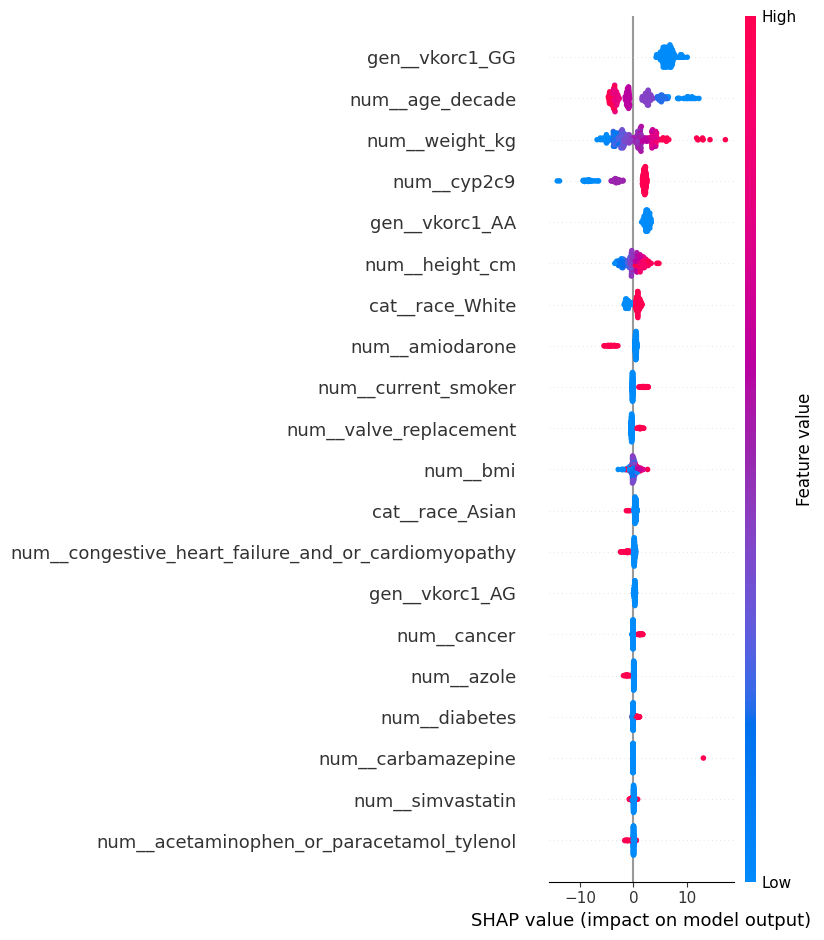

In [53]:
import shap
model = joblib.load(MODEL_PATH)
preprocessor = model.named_steps["preprocessor"]
xgb_model = model.named_steps["model"]


X_test=X_test[X_test['vkorc1']=='GG']

X_test_transformed = preprocessor.transform(X_test)
X_test_transformed=X_test_transformed
    
feature_names = preprocessor.get_feature_names_out()
 

explainer = shap.TreeExplainer(xgb_model,feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_transformed)
X_plot=pd.DataFrame(X_test_transformed.toarray() if hasattr(X_test_transformed,"toarray") else X_test_transformed,columns=feature_names)
 
shap.summary_plot(
        shap_values,
        X_plot,
        max_display=20,
        show=False)

In [65]:
hard_cases,easy_cases, comparison, genotype_comparison=analyse_hard_cases(X_test,y_test,pred,save=False)
hard_cases[['age_decade','weight_kg','height_cm','bmi','cyp2c9']].describe()

Hard cases (top 20%): 222
Easy cases (bottom 80%): 884

TOP FEATURES DRIVING ERROR (Hard vs Easy):
Feature
weight_kg                                         9.438657
height_cm                                         3.138846
bmi                                               3.011337
age_decade                                       -0.632806
acetaminophen_or_paracetamol_tylenol              0.134467
current_smoker                                    0.122662
valve_replacement                                -0.071202
cyp2c9                                            0.070243
azole                                             0.068515
diabetes                                          0.042552
hypertension                                      0.032856
anti_fungal_azoles                                0.032631
phenytoin                                         0.027007
congestive_heart_failure_and_or_cardiomyopathy   -0.026471
cancer                                            0.025712
Name: Di

,age_decade,weight_kg,height_cm,bmi,cyp2c9
count,222.000000,212.000000,168.000000,167.000000,222.000000
mean,5.355856,85.443396,170.930298,29.770510,1.851351
std,1.561539,24.903012,10.231779,8.035079,0.316189
min,2.000000,43.000000,142.010000,16.836011,0.500000
25%,4.000000,66.325000,162.560000,23.784176,2.000000
50%,5.000000,82.450000,171.325000,28.192195,2.000000
75%,6.000000,98.050000,178.687500,33.558047,2.000000
max,9.000000,177.300000,193.040000,56.084806,2.000000


In [66]:
y_pred_base = model.predict(X_test)
errors_base = np.abs(y_test - y_pred_base)
hard_error_mask = errors_base >= np.quantile(errors_base, 0.8)
baseline_hard_mae = errors_base[hard_error_mask].mean()
baseline_overall_mae = mean_absolute_error(y_test, y_pred_base)

print(f"BASELINE: Overall MAE={baseline_overall_mae:.2f}, Hard MAE={baseline_hard_mae:.2f}, N_hard={hard_error_mask.sum()}")
# ============================================

BASELINE: Overall MAE=9.45, Hard MAE=24.47, N_hard=222


In [68]:
X_test[hard_error_mask]['cyp2c9'].value_counts()


cyp2c9
2.0    175
1.5     30
1.0     15
0.5      2
Name: count, dtype: int64

In [69]:
X_test[hard_error_mask]['vkorc1'].value_counts()

vkorc1
UNKNOWN    92
GG         71
AG         44
AA         15
Name: count, dtype: int64

In [70]:
X_test[hard_error_mask][X_test[hard_error_mask]['cyp2c9']==2.0]['vkorc1'].value_counts()

vkorc1
UNKNOWN    76
GG         53
AG         32
AA         14
Name: count, dtype: int64

In [71]:
bins = [0, 21, 49, 1000]
labels = ['Low <21', 'Medium 21-49', 'High >49']
test_df['true_bin'] = pd.cut(test_df['true_dose'], bins=bins, labels=labels)
test_df['pred_bin'] = pd.cut(test_df['pred_dose'], bins=bins, labels=labels)
print(pd.crosstab(test_df['true_bin'], test_df['pred_bin'], normalize='index').round(2))

pred_bin      Low <21  Medium 21-49  High >49
true_bin                                     
Low <21          0.46          0.53      0.01
Medium 21-49     0.08          0.89      0.04
High >49         0.02          0.69      0.29


In [72]:
print(pd.crosstab(test_df['true_bin'],test_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
true_bin                                            
Low <21       0.526455  0.222222  0.058201  0.193122
Medium 21-49  0.157265  0.275214  0.256410  0.311111
High >49      0.020979  0.125874  0.468531  0.384615


In [73]:
print(pd.crosstab(test_df['pred_bin'],test_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
pred_bin                                            
Low <21       0.785714  0.120536  0.008929  0.084821
Medium 21-49  0.144431  0.281518  0.231334  0.342717
High >49      0.000000  0.092308  0.738462  0.169231


In [74]:
print(pd.crosstab(test_df['true_bin'],test_df['cyp2c9'],normalize='index'))

cyp2c9             0.0       0.5       1.0       1.5       2.0
true_bin                                                      
Low <21       0.007937  0.029101  0.177249  0.116402  0.669312
Medium 21-49  0.001709  0.006838  0.088889  0.143590  0.758974
High >49      0.000000  0.000000  0.048951  0.083916  0.867133


In [75]:
print(pd.crosstab(test_df['pred_bin'],test_df['cyp2c9'],normalize='index'))

cyp2c9             0.0       0.5       1.0       1.5       2.0
pred_bin                                                      
Low <21       0.008929  0.044643  0.254464  0.049107  0.642857
Medium 21-49  0.002448  0.006120  0.084455  0.151775  0.755202
High >49      0.000000  0.000000  0.000000  0.076923  0.923077


In [76]:
bins = [0, 21, 49, 1000]
labels = ['Low <21', 'Medium 21-49', 'High >49']
test_df['hard_error_mask']=hard_error_mask
hard_df=test_df[test_df['hard_error_mask']].copy()
hard_df['true_bin'] = pd.cut(hard_df['true_dose'], bins=bins, labels=labels)
hard_df['pred_bin'] = pd.cut(hard_df['pred_dose'], bins=bins, labels=labels)
print(pd.crosstab(hard_df['true_bin'], hard_df['pred_bin'], normalize='index').round(2))

pred_bin      Low <21  Medium 21-49  High >49
true_bin                                     
Low <21          0.03          0.92      0.05
Medium 21-49     0.12          0.72      0.16
High >49         0.03          0.76      0.21


In [77]:
print(pd.crosstab(hard_df['true_bin'],hard_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
true_bin                                            
Low <21       0.121212  0.242424  0.227273  0.409091
Medium 21-49  0.068966  0.258621  0.241379  0.431034
High >49      0.030612  0.132653  0.428571  0.408163


In [78]:
print(pd.crosstab(hard_df['pred_bin'],hard_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
pred_bin                                            
Low <21       0.416667  0.000000  0.083333  0.500000
Medium 21-49  0.056497  0.237288  0.237288  0.468927
High >49      0.000000  0.060606  0.848485  0.090909


In [79]:
print(pd.crosstab(hard_df['true_bin'],hard_df['cyp2c9'],normalize='index'))

cyp2c9             0.5       1.0       1.5       2.0
true_bin                                            
Low <21       0.000000  0.030303  0.212121  0.757576
Medium 21-49  0.034483  0.103448  0.137931  0.724138
High >49      0.000000  0.071429  0.081633  0.846939


In [80]:
print(pd.crosstab(hard_df['pred_bin'],hard_df['cyp2c9'],normalize='index'))

cyp2c9             0.5       1.0       1.5       2.0
pred_bin                                            
Low <21       0.166667  0.333333  0.083333  0.416667
Medium 21-49  0.000000  0.062147  0.152542  0.785311
High >49      0.000000  0.000000  0.060606  0.939394


In [81]:
df= pd.read_csv(RAW_DATA_PATH)
df.groupby('Race')['Cyp2C9 genotypes'].value_counts()

Race                       Cyp2C9 genotypes
Asian                      *1/*1               1457
                           *1/*3                103
                           *3/*3                  2
                           *1/*13                 1
                           *1/*14                 1
                           *1/*2                  1
Black or African American  *1/*1                391
                           *1/*2                 23
                           *1/*3                 10
                           *1/*5                  6
                           *1/*11                 5
                           *1/*6                  3
Unknown                    *1/*1                338
                           *1/*2                 92
                           *1/*3                 36
                           *2/*2                  6
                           *2/*3                  4
                           *3/*3                  3
White               

In [82]:
df.groupby('Race')['VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T'].value_counts()

Race                       VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T
Asian                      A/A                                                                  1109
                           A/G                                                                   210
                           G/G                                                                    15
Black or African American  G/G                                                                   250
                           A/G                                                                    51
                           A/A                                                                     5
Unknown                    A/G                                                                   110
                           G/G                                                                   108
                           A/A                                                                    2

In [84]:
pd.crosstab(df['Race'], df['VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T'], normalize='index').round(3)
pd.crosstab(df['Race'], df['Cyp2C9 genotypes'], normalize='index').round(3)

Cyp2C9 genotypes,*1/*1,*1/*11,*1/*13,*1/*14,*1/*2,*1/*3,*1/*5,*1/*6,*2/*2,*2/*3,*3/*3
Race,,,,,,,,,,,
Asian,0.931,0.000,0.001,0.001,0.001,0.066,0.000,0.000,0.000,0.000,0.001
Black or African American,0.893,0.011,0.000,0.000,0.053,0.023,0.014,0.007,0.000,0.000,0.000
Unknown,0.706,0.000,0.000,0.000,0.192,0.075,0.000,0.000,0.013,0.008,0.006
White,0.638,0.000,0.000,0.000,0.203,0.114,0.000,0.000,0.017,0.022,0.006


In [83]:
pd.crosstab(df['Race'], df['VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T'], normalize='index').round(3)

VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T,A/A,A/G,G/G
Race,,,
Asian,0.831,0.157,0.011
Black or African American,0.016,0.167,0.817
Unknown,0.117,0.445,0.437
White,0.145,0.489,0.366
